#### POREĐENJE MODELA

U ovoj svesci poredimo rezultate prethodno istreniranih modela:
- Baseline CNN model
- Metric learning model sa Triplet Loss funkcijom i KNN klasifikatorom
- Transfer learning model sa pretreniranim ResNet18 modelom

Modeli se porede na istom test skupu, uz iste metrike:
accuracy, precision, recall i F1-score.

#### UČITAVANJE PAKETA I PODATAKA

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

import joblib

In [2]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

baseline_model_path = Path("../models/baseline_cnn_best.pth")
metric_model_path = Path("../models/best_embedding_cnn_triplet.pth")
metric_knn_path = Path("../models/metric_learning_knn.joblib")
transfer_model_path = Path("../models/transfer_learning_resnet18_best.pth")

print("Train dir:", train_dir.resolve())
print("Test dir:", test_dir.resolve())
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

print("Baseline model exists:", baseline_model_path.exists())
print("Metric learning model exists:", metric_model_path.exists())
print("Metric KNN exists:", metric_knn_path.exists())
print("Transfer learning model exists:", transfer_model_path.exists())

print("Baseline path:", baseline_model_path.resolve())
print("Metric path:", metric_model_path.resolve())
print("Metric KNN path:", metric_knn_path.resolve())
print("Transfer path:", transfer_model_path.resolve())


IMG_SIZE_BASELINE = 64
IMG_SIZE_METRIC = 64
IMG_SIZE_TRANSFER = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
EMBEDDING_DIM = 64
DROPOUT_RATE = 0.3
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train dir: C:\Users\HS\Documents\GitHub\ML_projekat\data\tomatoleaf\tomato\train
Test dir: C:\Users\HS\Documents\GitHub\ML_projekat\data\tomatoleaf\tomato\val
Train exists: True
Test exists: True
Baseline model exists: True
Metric learning model exists: True
Metric KNN exists: True
Transfer learning model exists: True
Baseline path: C:\Users\HS\Documents\GitHub\ML_projekat\models\baseline_cnn_best.pth
Metric path: C:\Users\HS\Documents\GitHub\ML_projekat\models\best_embedding_cnn_triplet.pth
Metric KNN path: C:\Users\HS\Documents\GitHub\ML_projekat\models\metric_learning_knn.joblib
Transfer path: C:\Users\HS\Documents\GitHub\ML_projekat\models\transfer_learning_resnet18_best.pth
Device: cpu


#### TRANSFORMACIJA SLIKA

In [3]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() može da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogućava čitanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraća običnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")

#Moramo da imamo različite transformacije slika, jer modeli nisu trenirani sa istim veličinama.

baseline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_BASELINE, IMG_SIZE_BASELINE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

metric_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_METRIC, IMG_SIZE_METRIC)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transfer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
baseline_full_train_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=baseline_transform,
    loader=pil_loader_safe
)

baseline_test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=baseline_transform,
    loader=pil_loader_safe
)

metric_full_train_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=metric_transform,
    loader=pil_loader_safe
)

metric_test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=metric_transform,
    loader=pil_loader_safe
)

transfer_test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=transfer_transform,
    loader=pil_loader_safe
)

class_names = baseline_full_train_dataset.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(baseline_full_train_dataset))
print("Broj slika u test skupu:", len(baseline_test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10000
Broj slika u test skupu: 1000


U ovoj svesci se modeli ne treniraju ponovo, već se učitavaju prethodno sačuvani modeli iz foldera `models/`. Zbog toga imamo samo test loadere.

Za baseline CNN i transfer learning modele učitavaju se sačuvane `.pth` težine.  
Za metric learning pristup učitavaju se:
- embedding CNN model,
- prethodno sačuvani KNN klasifikator.

Na test skupu se zatim računaju predikcije i iste metrike za sva tri pristupa.

In [5]:
baseline_test_loader = DataLoader(
    baseline_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

metric_test_loader = DataLoader(
    metric_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

transfer_test_loader = DataLoader(
    transfer_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

- Moramo da iskopiramo klase modela u ovu svesku, da bismo mogle da učitamo najbolje modele.

#### Klasa za Baseline CNN model

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)
        x = self.fc(x)

        return x

#### Klasa za Metric Learning model

In [7]:
class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)
        return x

#### Klasa za Transfer Learning model

In [8]:
def create_resnet18_transfer_model(num_classes):
    weights = ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

#### Pomoćne funkcije za evaluaciju i računanje metrika

In [9]:
def evaluate_classifier(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predicted.cpu().numpy())

    return np.array(all_labels), np.array(all_predictions)


def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

#### Učitavanje najboljeg Baseline CNN modela

In [10]:
baseline_model = BaselineCNN(
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)

baseline_model.load_state_dict(
    torch.load(baseline_model_path, map_location=device)
)

baseline_model.eval()

baseline_y_true, baseline_y_pred = evaluate_classifier(
    baseline_model,
    baseline_test_loader,
    device
)

baseline_metrics = calculate_metrics(baseline_y_true, baseline_y_pred)

baseline_metrics

{'accuracy': 0.92,
 'precision': 0.9204903863710103,
 'recall': 0.92,
 'f1_score': 0.9198016175005072}

#### Učitavanje Metric Learning i KNN modela

Za metric learning pristup učitava se sačuvani embedding CNN model i sačuvani KNN klasifikator. Embedding CNN se koristi za izdvajanje embedding reprezentacija test slika, a zatim se klase predviđaju pomoću prethodno sačuvanog KNN modela.

In [11]:
def extract_embeddings_standard(model, loader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for images, label in loader:
            images = images.to(device)

            emb = model(images)

            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

In [12]:
embedding_model = EmbeddingCNN(
    embedding_dim=EMBEDDING_DIM
).to(device)

embedding_model.load_state_dict(
    torch.load(metric_model_path, map_location=device)
)

embedding_model.eval()

test_emb, test_labels = extract_embeddings_standard(
    embedding_model,
    metric_test_loader,
    device
)

knn = joblib.load(metric_knn_path)

knn_y_pred = knn.predict(test_emb)
knn_y_true = test_labels

knn_metrics = calculate_metrics(knn_y_true, knn_y_pred)

knn_metrics

C:\Users\HS\miniconda3\envs\torch_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


{'accuracy': 0.869,
 'precision': 0.8710967594134399,
 'recall': 0.869,
 'f1_score': 0.8688548026373027}

#### Učitavanje Transfer Learning modela

In [13]:
transfer_model = create_resnet18_transfer_model(
    num_classes=num_classes
).to(device)

transfer_model.load_state_dict(
    torch.load(transfer_model_path, map_location=device)
)

transfer_model.eval()

transfer_y_true, transfer_y_pred = evaluate_classifier(
    transfer_model,
    transfer_test_loader,
    device
)

transfer_metrics = calculate_metrics(
    transfer_y_true,
    transfer_y_pred
)

transfer_metrics

{'accuracy': 0.98,
 'precision': 0.980221358596286,
 'recall': 0.98,
 'f1_score': 0.9799141163569784}

#### TABELARNO POREĐENJE MODELA

In [14]:
results_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        **baseline_metrics
    },
    {
        "Model": "Metric Learning + KNN",
        **knn_metrics
    },
    {
        "Model": "Transfer Learning ResNet18",
        **transfer_metrics
    }
])

results_df

,Model,accuracy,precision,recall,f1_score
0,Baseline CNN,0.920,0.920490,0.920,0.919802
1,Metric Learning + KNN,0.869,0.871097,0.869,0.868855
2,Transfer Learning ResNet18,0.980,0.980221,0.980,0.979914


#### GRAFIČKO POREĐENJE MODELA

<Figure size 1000x600 with 0 Axes>

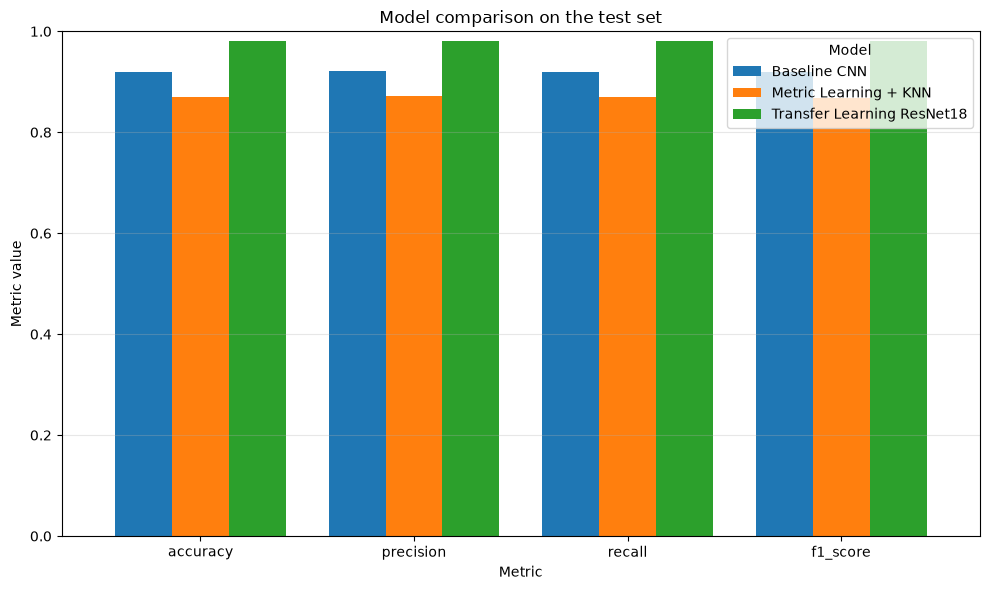

In [15]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]

plot_df = results_df.set_index("Model")[metrics_to_plot].T

plt.figure(figsize=(10, 6))

plot_df.plot(kind="bar", figsize=(10, 6), width=0.8)

plt.title("Model comparison on the test set")
plt.xlabel("Metric")
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### CLASSIFICATION REPORT

#### Baseline CNN model

In [16]:
print("Baseline CNN classification report:")
print(classification_report(
    baseline_y_true,
    baseline_y_pred,
    target_names=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    zero_division=0
))

Baseline CNN classification report:
                                      precision    recall  f1-score   support

                      Bacterial spot       0.92      0.93      0.93       100
                        Early blight       0.88      0.89      0.89       100
                         Late blight       0.84      0.85      0.85       100
                           Leaf Mold       0.94      0.87      0.90       100
                  Septoria leaf spot       0.94      0.91      0.92       100
Spider mites Two-spotted spider mite       0.89      0.89      0.89       100
                         Target Spot       0.90      0.96      0.93       100
       Tomato Yellow Leaf Curl Virus       0.97      0.90      0.93       100
                 Tomato mosaic virus       0.95      1.00      0.98       100
                             healthy       0.98      1.00      0.99       100

                            accuracy                           0.92      1000
                          

#### Metric Learning model

In [17]:
print("Metric Learning + KNN classification report:")
print(classification_report(
    knn_y_true,
    knn_y_pred,
    target_names=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    zero_division=0
))

Metric Learning + KNN classification report:
                                      precision    recall  f1-score   support

                      Bacterial spot       0.93      0.93      0.93       100
                        Early blight       0.79      0.82      0.80       100
                         Late blight       0.86      0.83      0.84       100
                           Leaf Mold       0.83      0.88      0.85       100
                  Septoria leaf spot       0.79      0.81      0.80       100
Spider mites Two-spotted spider mite       0.85      0.86      0.86       100
                         Target Spot       0.90      0.78      0.83       100
       Tomato Yellow Leaf Curl Virus       0.92      0.88      0.90       100
                 Tomato mosaic virus       0.87      1.00      0.93       100
                             healthy       0.98      0.90      0.94       100

                            accuracy                           0.87      1000
                 

#### Transfer Learning model

In [18]:
print("Transfer Learning ResNet18 classification report:")
print(classification_report(
    transfer_y_true,
    transfer_y_pred,
    target_names=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    zero_division=0
))

Transfer Learning ResNet18 classification report:
                                      precision    recall  f1-score   support

                      Bacterial spot       0.97      0.99      0.98       100
                        Early blight       0.99      0.94      0.96       100
                         Late blight       0.97      1.00      0.99       100
                           Leaf Mold       0.98      1.00      0.99       100
                  Septoria leaf spot       0.95      0.99      0.97       100
Spider mites Two-spotted spider mite       0.97      0.96      0.96       100
                         Target Spot       0.98      0.94      0.96       100
       Tomato Yellow Leaf Curl Virus       1.00      0.98      0.99       100
                 Tomato mosaic virus       1.00      1.00      1.00       100
                             healthy       0.99      1.00      1.00       100

                            accuracy                           0.98      1000
            

#### MATRICE KONFUZIJE

#### Baseline CNN model

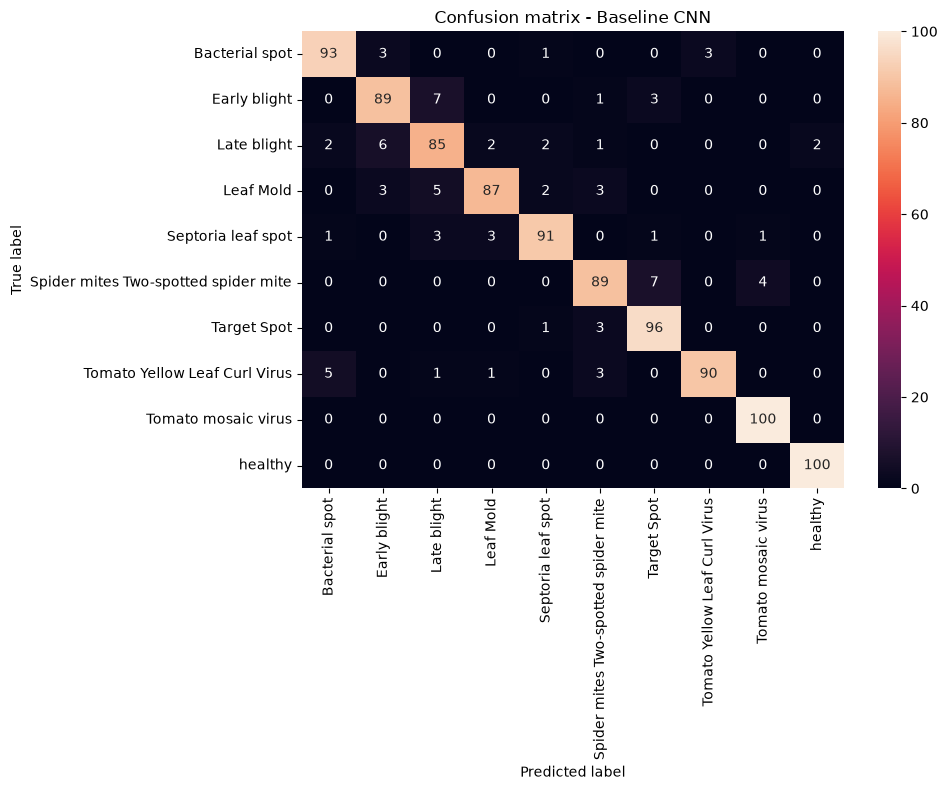

In [19]:
baseline_cm = confusion_matrix(baseline_y_true, baseline_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Baseline CNN")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Metric Learning model

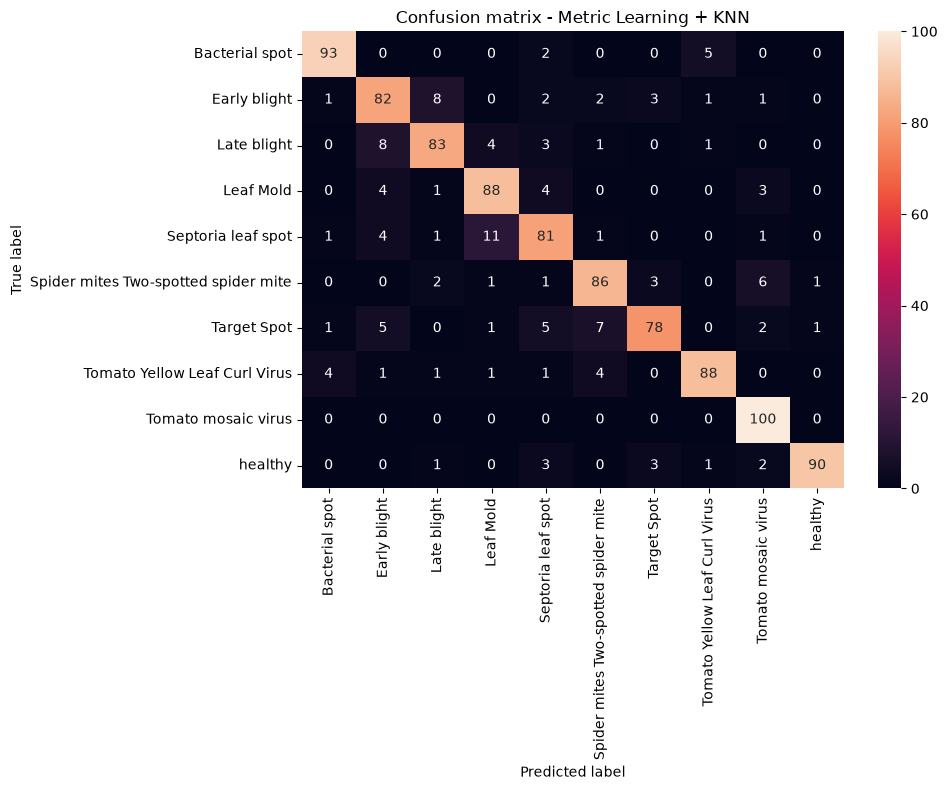

In [20]:
knn_cm = confusion_matrix(knn_y_true, knn_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Metric Learning + KNN")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Transfer Learning model

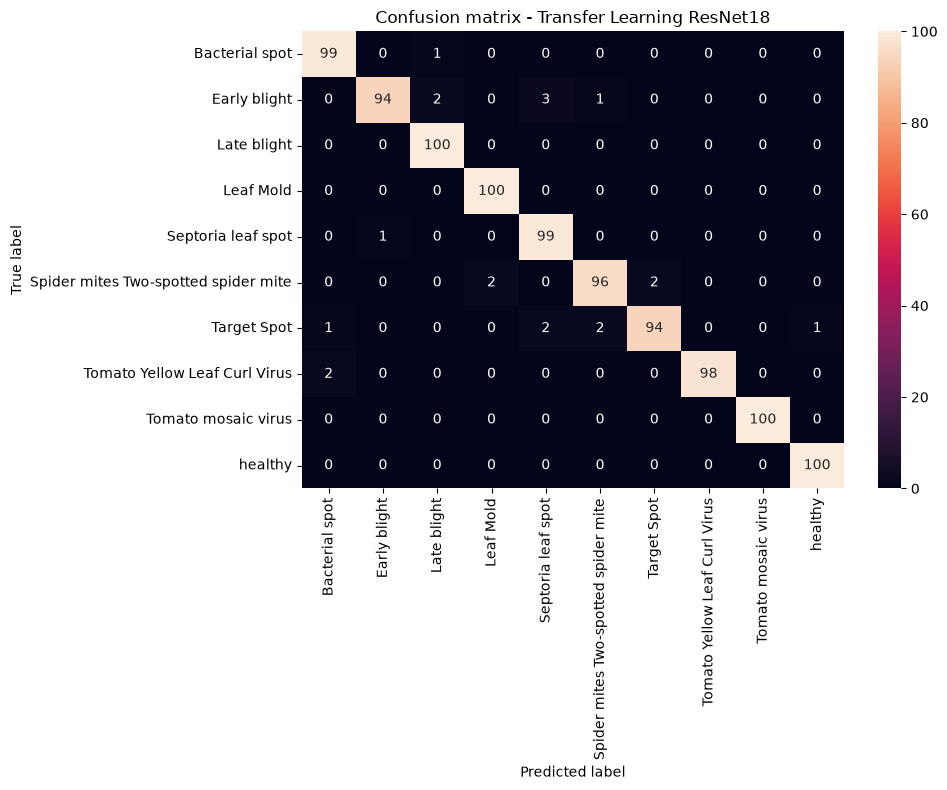

In [21]:
transfer_cm = confusion_matrix(transfer_y_true, transfer_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    transfer_cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Transfer Learning ResNet18")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Zaključak

Najbolji rezultat postigao je **Transfer Learning ResNet18** model, sa test tačnošću od 98.1%. Ovaj rezultat je očekivan, jer transfer learning koristi već naučene vizuelne karakteristike iz velikog skupa slika, što značajno pomaže kod klasifikacije slika listova.

**Baseline CNN** je postigao dobar rezultat od 92.2% tačnosti i predstavlja stabilan osnovni model za poređenje. Model je uspešno naučio relevantne vizuelne obrasce, ali slabije razlikuje neke vizuelno slične bolesti.

**Metric Learning + KNN** je dao slabiji rezultat od druga dva pristupa, sa tačnošću od 86.5%. Ipak, ovaj pristup je koristan jer pokazuje drugačiji način rešavanja problema: umesto direktne klasifikacije, model uči embedding prostor u kojem se slične slike grupišu.

Matrice konfuzije pokazuju da se najviše grešaka javlja između vizuelno sličnih bolesti lista, kao što su Early blight, Late blight, Leaf Mold, Target Spot i Spider mites.